# 05 Error Analysis

## Business Objective

This notebook examines where the tuned Phase 1 LightGBM model performs well and where it still makes larger prediction errors. The goal is to move beyond overall accuracy metrics and understand how model performance varies across terminals, dwell levels, and operating conditions.

This analysis helps identify whether prediction errors are concentrated in specific parts of the problem, such as high-dwell periods, certain yards, or conditions associated with congestion and resource tightness.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 20)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

print("Imports OK")

Imports OK


## Load and prepare the Phase 1 dataset

This notebook uses the same synthetic terminal dwell dataset and tuned LightGBM configuration established in the earlier notebooks. The objective here is not to search for new features, but to understand where the tuned model's predictions are strongest and where they still break down.

In [2]:
project_root = Path.cwd().resolve().parent
data_path = project_root / "data" / "synthetic" / "phase1_terminal_dwell.csv"

df = pd.read_csv(data_path, parse_dates=["date"])
df.columns = df.columns.str.strip()
df = df.sort_values(["terminal_id", "date"]).reset_index(drop=True)

print("Data path:", data_path)
print("Shape:", df.shape)

df.head()

Data path: /home/jorge/projects/rail-ops-forecaster/data/synthetic/phase1_terminal_dwell.csv
Shape: (8760, 13)


,date,terminal_id,terminal_name,region,inbound_train_count,inbound_car_count,cars_on_hand,yard_occupancy_pct,crew_starts_available,locomotive_availability_pct,is_weekend,month,target_dwell_hours
0,2022-01-01,T01,Barstow,West,13,304,532,59.100,13,92.300,1,1,19.700
1,2022-01-02,T01,Barstow,West,11,223,461,51.200,11,95.300,1,1,19.500
2,2022-01-03,T01,Barstow,West,10,219,448,49.800,18,85.700,0,1,20.000
3,2022-01-04,T01,Barstow,West,7,138,350,38.900,14,88.500,0,1,20.400
4,2022-01-05,T01,Barstow,West,9,175,361,40.100,17,90.500,0,1,20.700


In [3]:
target_col = "target_dwell_hours"

feature_cols = [
    "terminal_id",
    "inbound_train_count",
    "inbound_car_count",
    "cars_on_hand",
    "yard_occupancy_pct",
    "crew_starts_available",
    "locomotive_availability_pct",
    "is_weekend",
    "month",
]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Number of features:", len(feature_cols))
print("Target column:", target_col)

Number of features: 9
Target column: target_dwell_hours


In [4]:
split_date = "2024-07-01"

train_mask = df["date"] < split_date
test_mask = df["date"] >= split_date

X_train_full = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train_full = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

X_train_full["terminal_id"] = X_train_full["terminal_id"].astype("category")
X_test["terminal_id"] = X_test["terminal_id"].astype("category")

print("Train shape:", X_train_full.shape)
print("Test shape:", X_test.shape)

Train shape: (7296, 9)
Test shape: (1464, 9)


In [5]:
best_params = {
    "n_estimators": 200,
    "learning_rate": 0.03,
    "num_leaves": 15,
    "min_child_samples": 20
}

tuned_model = LGBMRegressor(
    objective="regression",
    random_state=42,
    **best_params
)

tuned_model.fit(
    X_train_full,
    y_train_full,
    categorical_feature=["terminal_id"]
)

y_test_pred = tuned_model.predict(X_test)

mse = mean_squared_error(y_test, y_test_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_test_pred)

print(f"Tuned test RMSE: {rmse:.3f}")
print(f"Tuned test MAE: {mae:.3f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000115 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1066
[LightGBM] [Info] Number of data points in the train set: 7296, number of used features: 9
[LightGBM] [Info] Start training from score 19.060458
Tuned test RMSE: 3.749
Tuned test MAE: 2.879


In [6]:
error_df = X_test.copy()
error_df["date"] = df.loc[test_mask, "date"].values
error_df["actual_dwell"] = y_test.values
error_df["predicted_dwell"] = y_test_pred
error_df["error"] = error_df["predicted_dwell"] - error_df["actual_dwell"]
error_df["absolute_error"] = error_df["error"].abs()

error_df.head()

,terminal_id,inbound_train_count,inbound_car_count,cars_on_hand,yard_occupancy_pct,crew_starts_available,locomotive_availability_pct,is_weekend,month,date,actual_dwell,predicted_dwell,error,absolute_error
912,T01,6,125,90,10.000,22,82.600,0,7,2024-07-01,18.200,21.175,2.975,2.975
913,T01,14,340,226,25.100,22,87.000,0,7,2024-07-02,16.500,20.235,3.735,3.735
914,T01,12,282,109,12.100,20,89.800,0,7,2024-07-03,20.400,20.414,0.014,0.014
915,T01,12,224,90,10.000,15,88.800,0,7,2024-07-04,17.700,20.556,2.856,2.856
916,T01,12,233,90,10.000,15,93.900,0,7,2024-07-05,18.400,20.759,2.359,2.359


## Overall error distribution

This section examines the distribution of signed and absolute errors on the test set. The goal is to understand whether the model usually makes small mistakes, whether a small number of large misses remain, and whether the model appears systematically biased toward overprediction or underprediction.

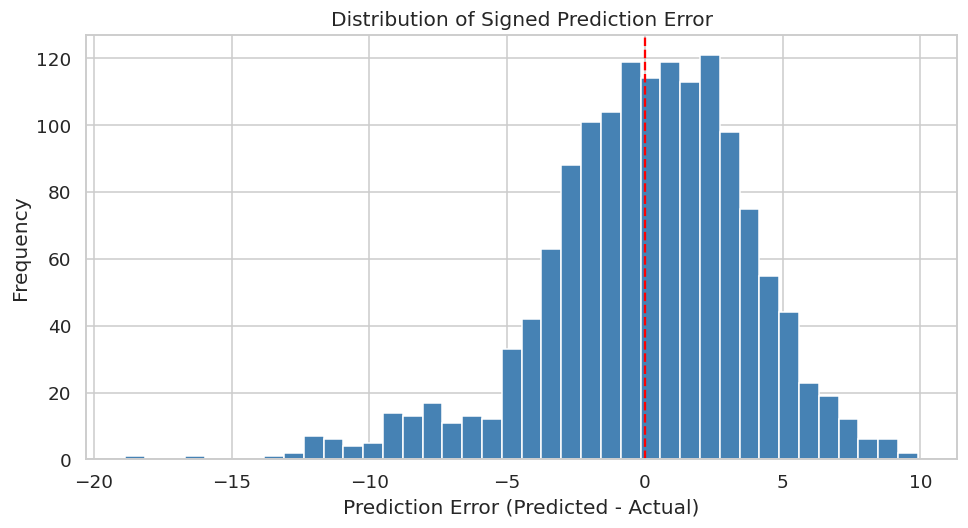

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(error_df["error"], bins=40, edgecolor="white", color="steelblue")
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_title("Distribution of Signed Prediction Error")
ax.set_xlabel("Prediction Error (Predicted - Actual)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

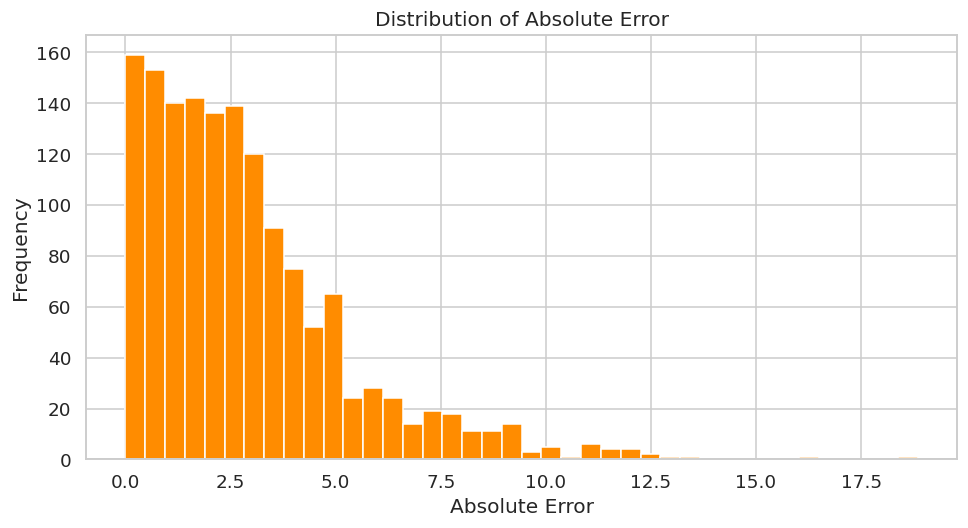

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(error_df["absolute_error"], bins=40, edgecolor="white", color="darkorange")
ax.set_title("Distribution of Absolute Error")
ax.set_xlabel("Absolute Error")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [9]:
error_summary = error_df[["error", "absolute_error"]].describe().T
error_summary

,count,mean,std,min,25%,50%,75%,max
error,1464.000,0.037,3.750,-18.848,-2.069,0.320,2.576,9.905
absolute_error,1464.000,2.879,2.402,0.001,1.134,2.359,3.869,18.848


## Largest prediction misses

This section identifies the observations with the largest absolute errors. Reviewing the worst misses helps show whether certain terminals, dates, or operating conditions are associated with the most difficult predictions.

In [10]:
worst_predictions = error_df.sort_values("absolute_error", ascending=False).head(10)

worst_predictions[
    [
        "date",
        "terminal_id",
        "actual_dwell",
        "predicted_dwell",
        "error",
        "absolute_error",
        "inbound_train_count",
        "inbound_car_count",
        "cars_on_hand",
        "yard_occupancy_pct",
        "crew_starts_available",
        "locomotive_availability_pct",
    ]
]

,date,terminal_id,actual_dwell,predicted_dwell,error,absolute_error,inbound_train_count,inbound_car_count,cars_on_hand,yard_occupancy_pct,crew_starts_available,locomotive_availability_pct
5328,2024-08-06,T05,39.500,20.652,-18.848,18.848,10,193,1107,92.200,37,96.400
1033,2024-10-30,T01,37.600,21.217,-16.383,16.383,15,358,98,10.900,17,85.600
2076,2024-09-08,T02,32.000,18.796,-13.204,13.204,13,314,110,10.000,17,87.200
8634,2024-08-27,T08,28.800,15.806,-12.994,12.994,7,185,59,14.800,12,91.400
8734,2024-12-05,T08,27.500,14.846,-12.654,12.654,5,112,40,10.000,7,82.400
2077,2024-09-09,T02,31.000,18.685,-12.315,12.315,16,425,121,11.000,14,83.800
997,2024-09-24,T01,33.200,20.974,-12.226,12.226,15,335,90,10.000,15,82.000
8674,2024-10-06,T08,27.700,15.603,-12.097,12.097,4,81,40,10.000,6,84.800
4298,2024-10-10,T04,33.800,21.755,-12.045,12.045,20,368,773,81.400,23,87.400
6493,2024-10-15,T06,28.300,16.415,-11.885,11.885,13,328,143,26.000,14,91.000


## Error by terminal

This section summarizes model error across terminals. If some terminals have consistently higher error than others, that may suggest either unmodeled local patterns or terminal-specific operating conditions that are not fully captured by the current feature set.

In [11]:
terminal_error_summary = (
    error_df.groupby("terminal_id")
    .agg(
        mean_error=("error", "mean"),
        mae=("absolute_error", "mean"),
        rmse_proxy=("error", lambda x: (x**2).mean() ** 0.5),
        n_obs=("absolute_error", "count")
    )
    .round(3)
    .sort_values("mae", ascending=False)
    .reset_index()
)

terminal_error_summary

,terminal_id,mean_error,mae,rmse_proxy,n_obs
0,T03,0.759,3.521,4.312,183
1,T04,-0.262,3.145,3.932,183
2,T01,0.064,2.964,3.883,183
3,T08,0.119,2.774,3.630,183
4,T05,-0.083,2.764,3.630,183
5,T06,-0.109,2.705,3.576,183
6,T02,0.062,2.592,3.534,183
7,T07,-0.252,2.570,3.419,183


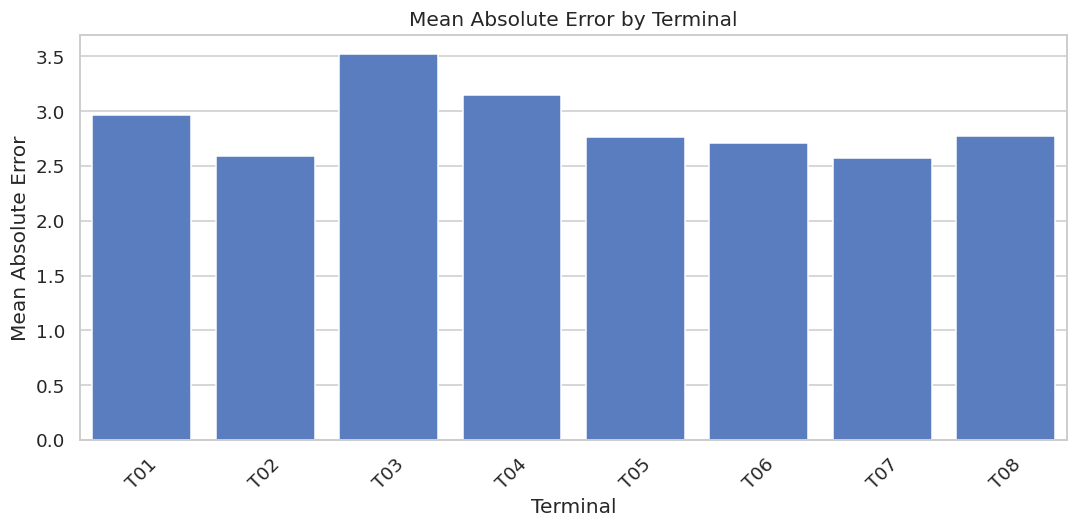

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(data=terminal_error_summary, x="terminal_id", y="mae")
plt.title("Mean Absolute Error by Terminal")
plt.xlabel("Terminal")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Error by dwell severity

This section checks whether the model performs differently across lower-dwell and higher-dwell observations. In many operational forecasting problems, extreme cases are harder to predict than normal cases.

In [13]:
error_df["dwell_band"] = pd.qcut(
    error_df["actual_dwell"],
    q=4,
    labels=["Low dwell", "Mid-low dwell", "Mid-high dwell", "High dwell"]
)

dwell_band_summary = (
    error_df.groupby("dwell_band")
    .agg(
        mean_actual_dwell=("actual_dwell", "mean"),
        mae=("absolute_error", "mean"),
        mean_error=("error", "mean"),
        n_obs=("absolute_error", "count")
    )
    .round(3)
    .reset_index()
)

dwell_band_summary

,dwell_band,mean_actual_dwell,mae,mean_error,n_obs
0,Low dwell,13.914,3.234,3.182,371
1,Mid-low dwell,17.574,2.174,1.203,367
2,Mid-high dwell,20.380,1.931,-0.220,361
3,High dwell,25.482,4.167,-4.077,365


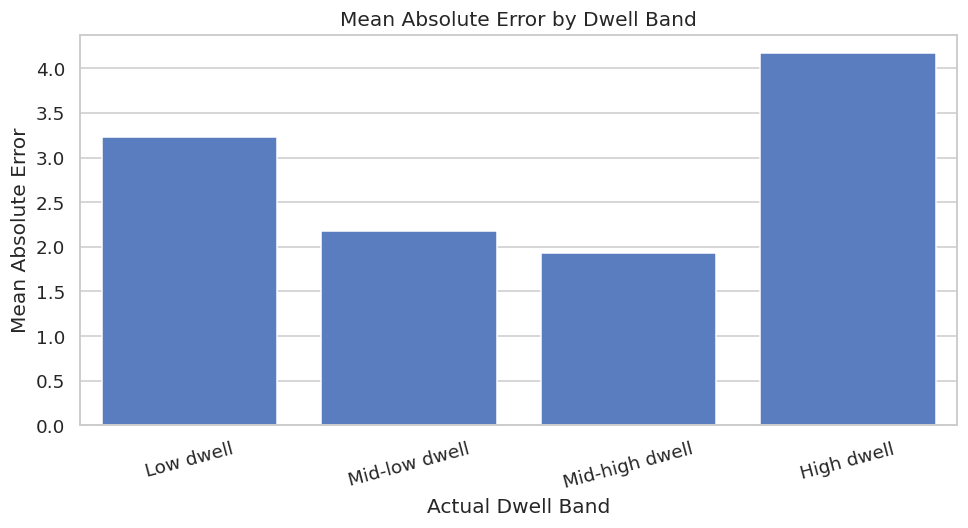

In [14]:
plt.figure(figsize=(9, 5))
sns.barplot(data=dwell_band_summary, x="dwell_band", y="mae")
plt.title("Mean Absolute Error by Dwell Band")
plt.xlabel("Actual Dwell Band")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Initial error-pattern interpretation

The tuned model's signed errors are roughly centered on zero overall, indicating limited systematic bias across the full test set. However, the error distribution has a heavier negative tail, driven by meaningful underpredictions in the most challenging cases.

**High-dwell extremes are the hardest cases.** The dwell-band analysis shows that the highest-dwell quartile carries the largest MAE and the most negative mean error — the model consistently underpredicts when actual dwell is furthest from the training mean. Two distinct mechanisms contribute to this:

- **Feature-visible failures**: cases where congestion-related features (high `yard_occupancy_pct`, large `cars_on_hand`, low `crew_starts_available`) are elevated but the model's prediction still falls short. These are, in principle, improvable with richer features or a larger model.
- **Spike-driven irreducible misses**: cases where the synthetic generator's random congestion event pushes actual dwell sharply upward with no corresponding signal in the available features. These are not fixable by tuning — they represent noise the feature set cannot see.

The worst misses in the top-10 table (absolute errors of 12–19 hours) are likely dominated by spike-driven events: actual dwell reaches 28–39 hours while predicted dwell stays near the terminal's learned baseline. Terminal-level analysis shows T03 (Galesburg) and T04 (Memphis) carry the highest per-terminal MAE, which may reflect either higher congestion-event frequency or larger spike magnitudes at those yards in the synthetic data.

## Overprediction vs underprediction

This section compares how often the model overpredicts and underpredicts dwell on the test set. A balanced model should show both types of error, but a meaningful skew toward one side may indicate systematic bias in certain operating conditions.

In [15]:
over_under_summary = pd.DataFrame({
    "error_type": ["Overprediction", "Underprediction", "Near zero (|error| < 0.1)"],
    "count": [
        (error_df["error"] > 0.1).sum(),
        (error_df["error"] < -0.1).sum(),
        (error_df["error"].abs() < 0.1).sum()
    ]
})

over_under_summary["percent"] = (over_under_summary["count"] / len(error_df) * 100).round(2)
over_under_summary

,error_type,count,percent
0,Overprediction,764,52.190
1,Underprediction,664,45.360
2,Near zero (|error| < 0.1),36,2.460


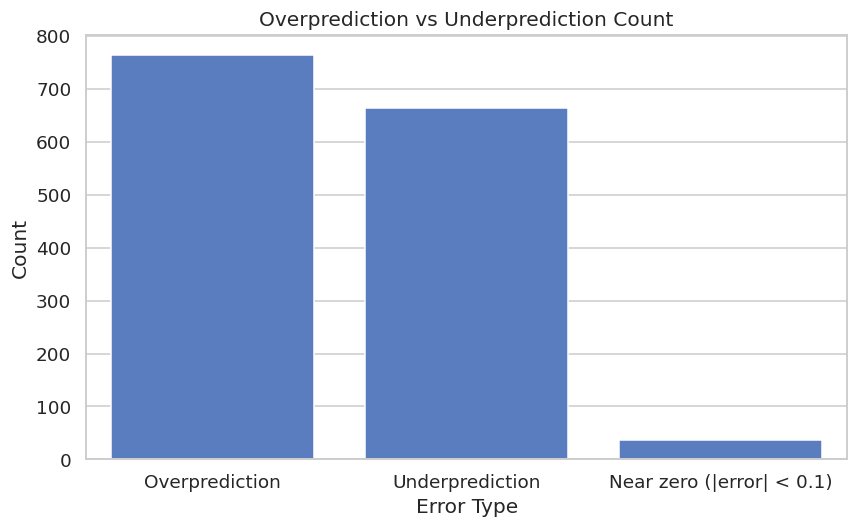

In [16]:
plt.figure(figsize=(8, 5))
sns.barplot(data=over_under_summary, x="error_type", y="count")
plt.title("Overprediction vs Underprediction Count")
plt.xlabel("Error Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Actual vs predicted comparison

A scatterplot of actual versus predicted dwell helps show how closely the model tracks the true values. If the model were perfect, all points would lie on the 45-degree reference line.

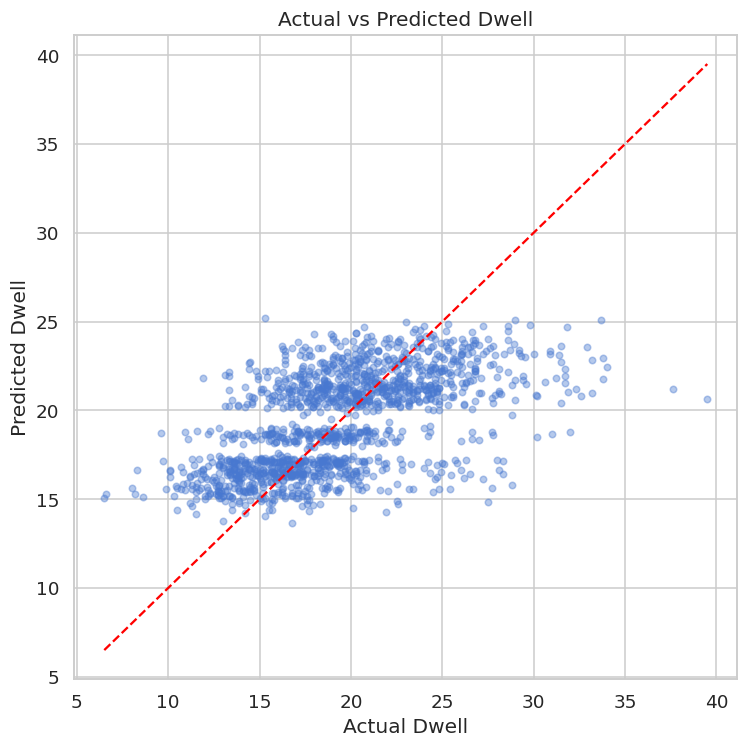

In [17]:
plt.figure(figsize=(7, 7))
plt.scatter(error_df["actual_dwell"], error_df["predicted_dwell"], alpha=0.4, s=18)
plt.plot(
    [error_df["actual_dwell"].min(), error_df["actual_dwell"].max()],
    [error_df["actual_dwell"].min(), error_df["actual_dwell"].max()],
    color="red",
    linestyle="--",
    linewidth=1.5
)
plt.xlabel("Actual Dwell")
plt.ylabel("Predicted Dwell")
plt.title("Actual vs Predicted Dwell")
plt.tight_layout()
plt.show()

## Residual pattern by predicted value

This plot checks whether prediction errors behave differently across the model's predicted range. If residual spread increases for larger predicted values, that may indicate heteroskedasticity or harder-to-model conditions in the upper tail.

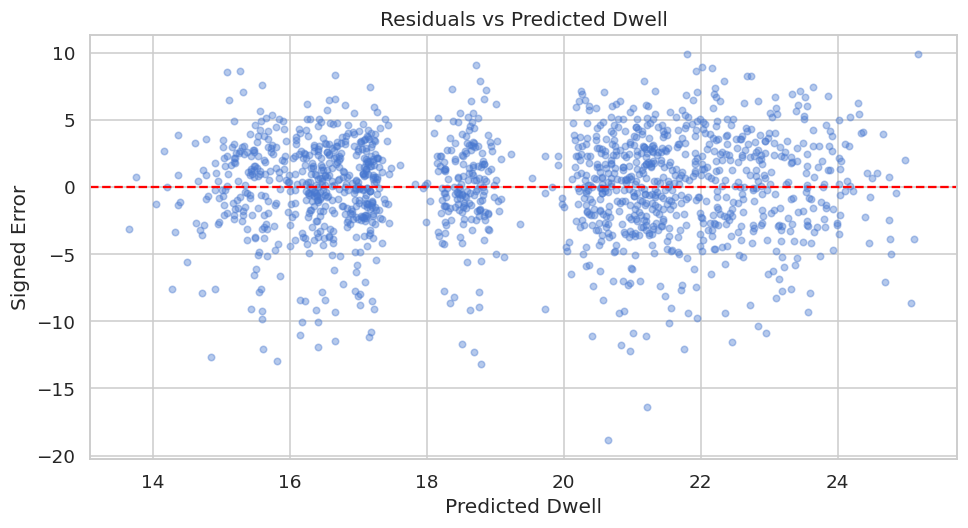

In [18]:
plt.figure(figsize=(9, 5))
plt.scatter(error_df["predicted_dwell"], error_df["error"], alpha=0.4, s=18)
plt.axhline(0, color="red", linestyle="--", linewidth=1.5)
plt.xlabel("Predicted Dwell")
plt.ylabel("Signed Error")
plt.title("Residuals vs Predicted Dwell")
plt.tight_layout()
plt.show()

## Conclusion

The tuned Phase 1 LightGBM model performs well across the middle of the dwell distribution but has a clear and concentrated weakness in the high-dwell tail. Error analysis reveals that the model's remaining failures are not evenly distributed — they cluster around the most extreme dwell outcomes.

Two types of failure are present. The first is **feature-visible**: elevated occupancy, high cars-on-hand, or constrained crew availability that the model partially responds to but does not fully correct for. These cases are in principle improvable — richer features or more granular terminal-level context could help. The second is **spike-driven and largely irreducible**: random congestion events embedded in the synthetic generator that produce sharp dwell spikes with no prior warning in the observable feature set. The model's prediction stays near the terminal's learned baseline while actual dwell jumps 10–20 hours above it. These misses cannot be closed through parameter tuning alone.

Terminal-level results show that T03 (Galesburg) and T04 (Memphis) are harder to forecast than other yards. Dwell-band results confirm that the low- and mid-dwell segments have meaningfully lower error than the high-dwell segment, where mean error turns sharply negative.

These findings provide clear direction: later phases should focus on distinguishing spike-driven from feature-driven high-dwell events, and should explore whether additional signals — disruption flags, weather, or interchange delay indicators — can make more of the high-dwell tail predictable rather than irreducible.